# 02  -  Data Preprocessing Pipeline
7-step pipeline across all three domains.

**Inputs:** `data/fraudTrain.csv`, `data/fraudTest.csv`, `data/MoMTSim_transactions.csv`, `outputs/health_insurance_labeled.csv`  
**Outputs:** `outputs/*_processed.csv`

In [1]:
exec(open('00_config.py').read())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.impute import KNNImputer
import warnings
warnings.filterwarnings('ignore')

Config loaded. BASE_DIR: /home/compute.ashesi.lan/sedem.agudetse/UniFraud-GH


## 1. Load Raw Datasets

In [2]:
# Credit card: combine train + test splits from Sparkov dataset
cc_parts = []
for p in [CREDIT_CARD_TRAIN_CSV, CREDIT_CARD_TEST_CSV]:
    if os.path.exists(p):
        cc_parts.append(pd.read_csv(p, index_col=0))

if not cc_parts:
    raise FileNotFoundError("fraudTrain.csv / fraudTest.csv not found in data/")

cc = pd.concat(cc_parts, ignore_index=True)
cc = cc.rename(columns={CC_RAW_TARGET: TARGET_COL})
cc = cc.drop(columns=[c for c in ['Unnamed: 0','trans_num','unix_time'] if c in cc.columns], errors='ignore')

# Mobile money
for mm_path in [MOMSIM_CSV, MOMSIM_CSV_ALT]:
    if os.path.exists(mm_path):
        mm = pd.read_csv(mm_path)
        break
else:
    raise FileNotFoundError("MoMTSim_transactions.csv not found in data/")

if 'isFraud' in mm.columns:
    mm = mm.rename(columns={'isFraud': TARGET_COL})

# Health insurance (labeled in NB01)
hi = pd.read_csv(HI_LABELED_CSV)

print(f'CC : {cc.shape}  fraud={cc[TARGET_COL].mean():.3%}')
print(f'MM : {mm.shape}  fraud={mm[TARGET_COL].mean():.3%}')
print(f'HI : {hi.shape}  fraud={hi[TARGET_COL].mean():.3%}')

CC : (1852394, 20)  fraud=0.521%
MM : (550358, 10)  fraud=54.843%
HI : (2655, 36)  fraud=41.620%


## 2. Preprocessing Function

In [3]:
def preprocess_domain(df, domain_name, drop_cols=None, time_col=None):
    """
    7-step pipeline: drop cols -> missing values ->outlier capping ->
    scaling -> encoding -> temporal features -> split.
    """
    print(f'\n{domain_name}  ({df.shape})')
    df = df.copy()
    y  = df.pop(TARGET_COL)

    if drop_cols:
        existing = [c for c in drop_cols if c in df.columns]
        df = df.drop(columns=existing)
        print(f'  [0] Dropped: {existing}')

    #Step 1: missing values
    miss_pct   = df.isnull().mean()
    high_miss  = miss_pct[miss_pct > MISSING_DROP_THRESHOLD].index.tolist()
    df = df.drop(columns=high_miss)
    num_cols = df.select_dtypes(include=np.number).columns.tolist()
    cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()
    if df[num_cols].isnull().any().any():
        df[num_cols] = KNNImputer(n_neighbors=KNN_IMPUTE_K).fit_transform(df[num_cols])
    for col in cat_cols:
        if df[col].isnull().any():
            df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'Unknown', inplace=True)
    print(f'  [1] Missing: dropped {len(high_miss)} cols, imputed rest')

    # Step 2: outlier capping at 99th percentile
    cap = OUTLIER_CAP_PERCENTILE / 100
    for col in num_cols:
        if col in df.columns:
            df[col] = df[col].clip(upper=df[col].quantile(cap))
    print(f'  [2] Capped at {OUTLIER_CAP_PERCENTILE}th percentile')

    # Step 3: scaling  -  Standard for near-normal cols, Robust for skewed
    from scipy.stats import normaltest
    std_cols, robust_cols = [], []
    for col in num_cols:
        if col in df.columns and df[col].nunique() > 2:
            try:
                _, p = normaltest(df[col].dropna())
                (std_cols if p > 0.05 else robust_cols).append(col)
            except Exception:
                robust_cols.append(col)
    if std_cols:    df[std_cols]    = StandardScaler().fit_transform(df[std_cols])
    if robust_cols: df[robust_cols] = RobustScaler().fit_transform(df[robust_cols])
    print(f'  [3] Standard: {len(std_cols)}  Robust: {len(robust_cols)}')

    # Step 4: encoding
    low_card  = [c for c in cat_cols if c in df.columns and df[c].nunique() <= 10]
    high_card = [c for c in cat_cols if c in df.columns and df[c].nunique()  > 10]
    if low_card:
        df = pd.get_dummies(df, columns=low_card, drop_first=True)
    if high_card:
        global_mean = y.mean()
        for col in high_card:
            stats = y.groupby(df[col]).agg(['mean','count'])
            k = 10
            stats['smooth'] = (stats['mean'] * stats['count'] + global_mean * k) / (stats['count'] + k)
            df[col] = df[col].map(stats['smooth']).fillna(global_mean)
    print(f'  [4] One-hot: {len(low_card)}  Target-encoded: {len(high_card)}')

    # Step 5: temporal features
    if time_col and time_col in df.columns:
        ts = pd.to_datetime(df[time_col])
        df['hour_of_day'] = ts.dt.hour
        df['day_of_week'] = ts.dt.dayofweek
        df['is_weekend']  = (ts.dt.dayofweek >= 5).astype(int)
        df['hour_sin']    = np.sin(2 * np.pi * ts.dt.hour / 24)
        df['hour_cos']    = np.cos(2 * np.pi * ts.dt.hour / 24)
        peak = set(range(7,10)) | set(range(12,15)) | set(range(17,21))
        df['unusual_hour'] = (~ts.dt.hour.isin(peak)).astype(int)
        df = df.drop(columns=[time_col])
    elif 'step' in df.columns:
        # MoMTSim 'step' = simulation hour
        df['hour_of_sim'] = df['step'] % 24
        df['day_of_sim']  = df['step'] // 24
        df['hour_sin']    = np.sin(2 * np.pi * df['hour_of_sim'] / 24)
        df['hour_cos']    = np.cos(2 * np.pi * df['hour_of_sim'] / 24)
        peak = set(range(7,10)) | set(range(12,15)) | set(range(17,21))
        df['unusual_hour'] = (~df['hour_of_sim'].isin(peak)).astype(int)
        df = df.drop(columns=['step','hour_of_sim'])
    print(f'  [5] Temporal features extracted')

    # Step 6: class imbalance note (SMOTE applied in NB05)
    print(f'  [6] Legitimate: {(y==0).sum():,}  Fraud: {(y==1).sum():,}')

    # Step 7: train / val / test split
    from sklearn.model_selection import train_test_split
    X = df.reset_index(drop=True)
    y = y.reset_index(drop=True)
    valid = y.notna()
    X, y = X[valid].reset_index(drop=True), y[valid].astype(int).reset_index(drop=True)

    X_tv, X_test, y_tv, y_test = train_test_split(X, y, test_size=TEST_RATIO, stratify=y, random_state=RANDOM_STATE)
    val_rel = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
    X_train, X_val, y_train, y_val = train_test_split(X_tv, y_tv, test_size=val_rel, stratify=y_tv, random_state=RANDOM_STATE)
    print(f'  [7] Train:{len(X_train):,}  Val:{len(X_val):,}  Test:{len(X_test):,}')

    X[TARGET_COL] = y.values
    return X, (X_train, X_val, X_test, y_train, y_val, y_test)

print('Preprocessing function defined')

Preprocessing function defined


## 3. Preprocess Credit Card

In [4]:
cc_drop = [c for c in ['cc_num','first','last','street','city','zip','trans_num','unix_time'] if c in cc.columns]

cc_processed, cc_splits = preprocess_domain(
    cc, 'Credit Card',
    drop_cols=cc_drop,
    time_col='trans_date_trans_time'
)
cc_processed.to_csv(CC_PROCESSED_CSV, index=False)
print(f'Saved -> {CC_PROCESSED_CSV}')


Credit Card  ((1852394, 20))
  [0] Dropped: ['cc_num', 'first', 'last', 'street', 'city', 'zip']
  [1] Missing: dropped 0 cols, imputed rest
  [2] Capped at 99th percentile
  [3] Standard: 0  Robust: 6
  [4] One-hot: 1  Target-encoded: 6
  [5] Temporal features extracted
  [6] Legitimate: 1,842,743  Fraud: 9,651
  [7] Train:1,296,675  Val:277,859  Test:277,860
Saved -> /home/compute.ashesi.lan/sedem.agudetse/UniFraud-GH/outputs/credit_card_processed.csv


## 4. Preprocess Mobile Money

In [5]:
mm_drop = [c for c in ['nameOrig','nameDest','isFlaggedFraud','type'] if c in mm.columns]

# Drop rows with NaN target if any
mm = mm.dropna(subset=[TARGET_COL])
mm[TARGET_COL] = mm[TARGET_COL].astype(int)

mm_processed, mm_splits = preprocess_domain(mm, 'Mobile Money', drop_cols=mm_drop)
mm_processed.to_csv(MM_PROCESSED_CSV, index=False)
print(f'Saved -> {MM_PROCESSED_CSV}')


Mobile Money  ((550357, 10))
  [1] Missing: dropped 0 cols, imputed rest
  [2] Capped at 99th percentile
  [3] Standard: 0  Robust: 7
  [4] One-hot: 1  Target-encoded: 1
  [5] Temporal features extracted
  [6] Legitimate: 248,525  Fraud: 301,832
  [7] Train:385,249  Val:82,554  Test:82,554
Saved -> /home/compute.ashesi.lan/sedem.agudetse/UniFraud-GH/outputs/mobile_money_processed.csv


## 5. Preprocess Health Insurance

In [6]:
hi_drop = [c for c in ['source_file','overbill_service','overbill_medical','overbill_total',
                        'billing_inconsistency','impossible_amount'] if c in hi.columns]

hi_processed, hi_splits = preprocess_domain(hi, 'Health Insurance', drop_cols=hi_drop)
hi_processed.to_csv(HI_PROCESSED_CSV, index=False)
print(f'Saved -> {HI_PROCESSED_CSV}')


Health Insurance  ((2655, 36))
  [0] Dropped: ['source_file', 'overbill_service', 'overbill_total', 'billing_inconsistency', 'impossible_amount']
  [1] Missing: dropped 6 cols, imputed rest
  [2] Capped at 99th percentile
  [3] Standard: 0  Robust: 7
  [4] One-hot: 3  Target-encoded: 9
  [5] Temporal features extracted
  [6] Legitimate: 1,550  Fraud: 1,105
  [7] Train:1,857  Val:399  Test:399
Saved -> /home/compute.ashesi.lan/sedem.agudetse/UniFraud-GH/outputs/health_insurance_processed.csv


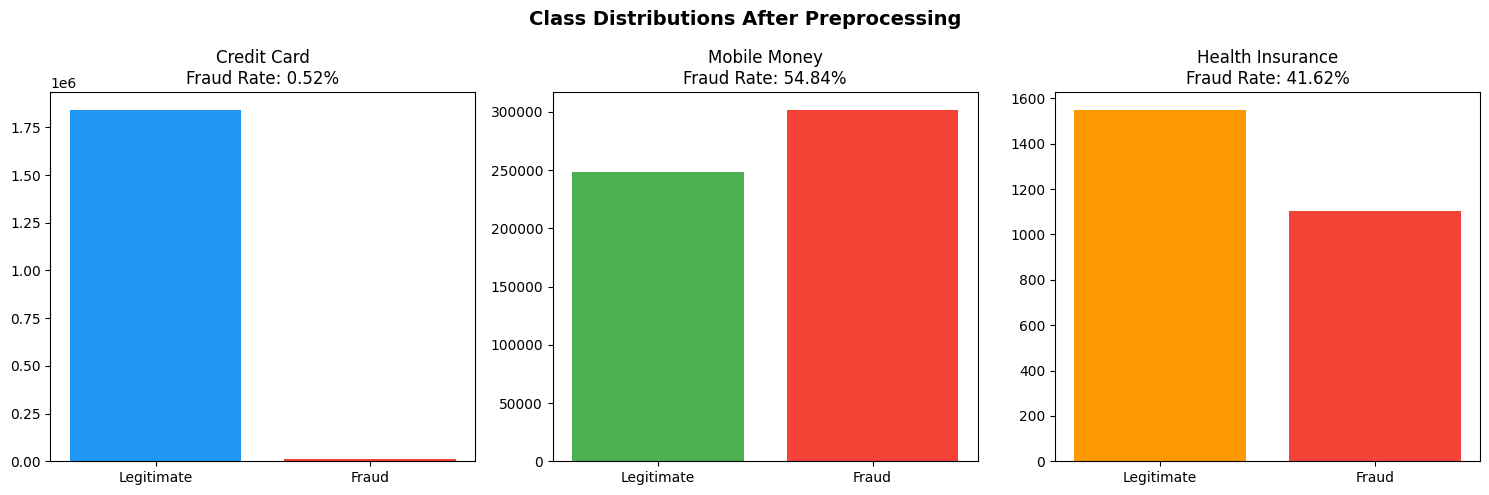

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#2196F3', '#4CAF50', '#FF9800']

for ax, name, df_, clr in zip(axes,
    ['Credit Card','Mobile Money','Health Insurance'],
    [cc_processed, mm_processed, hi_processed], colors):
    counts = df_[TARGET_COL].value_counts()
    ax.bar(['Legitimate','Fraud'], [counts.get(0,0), counts.get(1,0)], color=[clr,'#F44336'])
    ax.set_title(f'{name}\nFraud Rate: {df_[TARGET_COL].mean():.2%}')

plt.suptitle('Class Distributions After Preprocessing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, '02_class_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()